In [2]:
import torch

def mask_to_box(mask):
    ys, xs = np.where(mask == 1)
    if len(xs) == 0:
        return None
    return [xs.min(), ys.min(), xs.max(), ys.max()]
    
def targets_from_multiclass_mask(mask_hw: torch.Tensor, class_ids=(1,2,3,4), min_pixels=50):
    # mask_hw: HxW with values 0..4
    boxes, labels = [], []
    for cid in class_ids:
        m = (mask_hw == cid)
        if m.sum().item() < min_pixels:
            continue
        box = mask_to_box(m)
        if box is None:
            continue
        boxes.append(box)
        labels.append(cid)

    if len(boxes) == 0:
        boxes = torch.zeros((0,4), dtype=torch.float32)
        labels = torch.zeros((0,), dtype=torch.int64)
    else:
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

    return {"boxes": boxes, "labels": labels}

    import numpy as np

def rle_decode(mask_rle, shape=(1400, 2100)):
    """
    mask_rle: string of numbers
    shape: (height, width)
    """
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)

    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0::2], s[1::2])]
    starts -= 1
    ends = starts + lengths

    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)

    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    return img.reshape(shape).T  # IMPORTANT: transpose!

In [3]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF

# ----- RLE decode for Kaggle Cloud dataset (column-major; needs transpose) -----
def rle_decode(mask_rle, shape=(1400, 2100)):
    """
    mask_rle: string like "start length start length ..."
    shape: (H, W)
    returns: np.uint8 mask HxW in {0,1}
    """
    if mask_rle is None or (isinstance(mask_rle, float) and np.isnan(mask_rle)) or mask_rle == "":
        return np.zeros(shape, dtype=np.uint8)

    s = mask_rle.split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    # Kaggle clouds are encoded column-wise
    return img.reshape((shape[1], shape[0])).T  # -> (H,W)

def mask_to_box(mask_hw):
    ys, xs = np.where(mask_hw == 1)
    if xs.size == 0:
        return None
    return [xs.min(), ys.min(), xs.max(), ys.max()]  # x1,y1,x2,y2

class CloudDetDataset(Dataset):
    """
    Works for both train and test.

    Train usage: provide csv_path with EncodedPixels.
    Test usage: omit csv_path (or provide None) -> returns images + image_id only.

    Returns:
      - train: (image_tensor, target_dict)
      - test:  (image_tensor, image_id_str)
        (or you can set return_empty_target=True to return empty targets for unified loops)
    """
    LABEL_MAP = {"Fish": 1, "Flower": 2, "Gravel": 3, "Sugar": 4}

    def __init__(
        self,
        image_dir: str,
        csv_path: str | None = None,
        image_size: tuple[int, int] | None = (320, 320),  # set None to keep original size
        return_empty_target: bool = False,               # helpful if you want a single eval loop signature
        mask_shape: tuple[int, int] = (1400, 2100),      # original mask H,W for RLE decode
        min_pixels: int = 50,                            # ignore tiny masks
    ):
        self.image_dir = image_dir
        self.image_size = image_size
        self.return_empty_target = return_empty_target
        self.mask_shape = mask_shape
        self.min_pixels = min_pixels

        self.df = None
        if csv_path is not None:
            df = pd.read_csv(csv_path)
            df["Image"] = df["Image_Label"].apply(lambda x: x.split("_")[0])
            df["Label"] = df["Image_Label"].apply(lambda x: x.split("_")[1])
            self.df = df

            # Keep images listed in CSV (train set)
            self.images = sorted(df["Image"].unique().tolist())
        else:
            # Test set: just list image files
            self.images = sorted([
                f for f in os.listdir(image_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_id = self.images[idx]
        img_path = os.path.join(self.image_dir, image_id)

        pil = Image.open(img_path).convert("RGB")
        orig_w, orig_h = pil.size

        # Optional resize for speed/memory
        if self.image_size is not None:
            new_w, new_h = self.image_size
            pil_resized = pil.resize((new_w, new_h), resample=Image.BILINEAR)
            image = TF.to_tensor(pil_resized)
            sx = new_w / orig_w
            sy = new_h / orig_h
        else:
            image = TF.to_tensor(pil)
            sx = sy = 1.0

        # ---- TEST MODE (no labels) ----
        if self.df is None:
            if self.return_empty_target:
                target = {
                    "boxes": torch.zeros((0, 4), dtype=torch.float32),
                    "labels": torch.zeros((0,), dtype=torch.int64),
                    "image_id": torch.tensor([idx]),
                }
                return image, target
            return image, image_id

        # ---- TRAIN MODE (build boxes/labels from RLE) ----
        rows = self.df[self.df["Image"] == image_id]

        boxes = []
        labels = []

        for _, row in rows.iterrows():
            rle = row["EncodedPixels"]
            if rle is None or (isinstance(rle, float) and np.isnan(rle)) or rle == "":
                continue

            mask = rle_decode(rle, shape=self.mask_shape)
            if mask.sum() < self.min_pixels:
                continue

            box = mask_to_box(mask)
            if box is None:
                continue

            # Scale box if we resized the image
            x1, y1, x2, y2 = box
            x1, x2 = x1 * sx, x2 * sx
            y1, y2 = y1 * sy, y2 * sy
            boxes.append([x1, y1, x2, y2])
            labels.append(self.LABEL_MAP[row["Label"]])

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
        }

        return image, target


def collate_fn(batch):
    # Works for detection models (variable number of boxes per image)
    return tuple(zip(*batch))


In [4]:
train_ds = CloudDetDataset(
    image_dir="train_images",
    csv_path="train.csv",
    image_size=(320, 320),       # change to (512,512) if you want better accuracy
)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn
)

test_ds = CloudDetDataset(
    image_dir="test_images",
    csv_path=None,
    image_size=(320, 320),
)

test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=4, shuffle=False, collate_fn=collate_fn
)

In [5]:
import torchvision
model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/ssdlite320_mobilenet_v3_large_coco-a79551df.pth" to C:\Users\jason/.cache\torch\hub\checkpoints\ssdlite320_mobilenet_v3_large_coco-a79551df.pth


100%|██████████| 13.4M/13.4M [00:00<00:00, 17.8MB/s]


In [ ]:
num_classes = 5  # background + 4 cloud types
# In many torchvision versions, SSD models accept num_classes at construction:
model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(weights="DEFAULT", num_classes=num_classes)

In [8]:
import torch
from torch.utils.data import DataLoader

num_epochs = 1
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

model.train()
for epoch in range(num_epochs):
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(epoch, float(loss))

0 4.2548956871032715


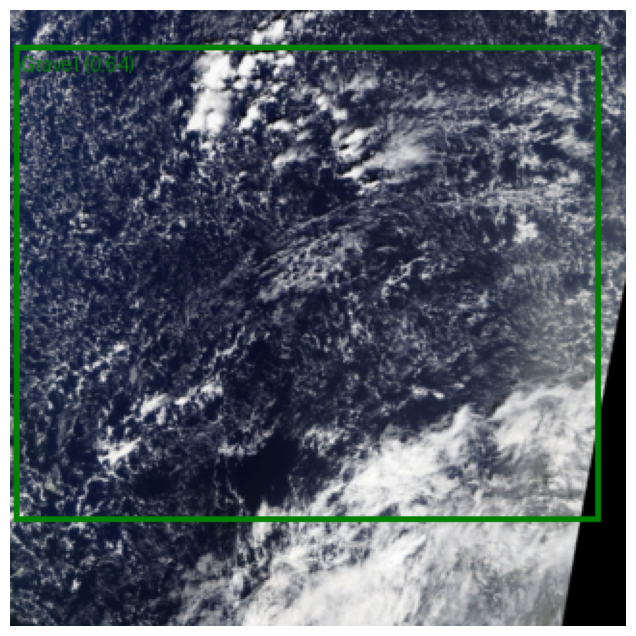

In [18]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

model.eval()

# Get one image
image, image_id = test_ds[0]

with torch.no_grad():
    pred = model([image.to(device)])[0]

score_thresh = 0.4

boxes = pred["boxes"].cpu()
labels = pred["labels"].cpu()
scores = pred["scores"].cpu()

# Filter low-confidence detections
keep = scores >= score_thresh
boxes = boxes[keep]
labels = labels[keep]
scores = scores[keep]

# Convert image to uint8 for drawing
image_uint8 = (image * 255).to(torch.uint8)

# Map numeric labels → readable class names
label_map = {
    1: "Fish",
    2: "Flower",
    3: "Gravel",
    4: "Sugar"
}

# Build label text strings
label_text = [
    f"{label_map[int(cls)]} ({score:.2f})"
    for cls, score in zip(labels, scores)
]

# Draw boxes + labels
color_map = {
    1: "red",
    2: "blue",
    3: "green",
    4: "yellow"
}

colors = [color_map[int(cls)] for cls in labels]

vis = draw_bounding_boxes(
    image_uint8,
    boxes,
    labels=label_text,
    colors=colors,
    width=3
)

# Display
plt.figure(figsize=(8,8))
plt.imshow(vis.permute(1,2,0))
plt.axis("off")
plt.show()